In [ ]:
# IMPORTING NECESSARY LIBRARIES

import numpy as np
import pandas as pd
import os
import pathlib
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import cv2
from skimage.feature import hog
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

# Silence some TensorFlow warnings
tf.get_logger().setLevel('ERROR')

In [ ]:

MODEL_PATH = '/kaggle/input/my-deep-net-model/keras/default/1/my_deepfake_detector.keras' 
CSV_PATH = '/kaggle/input/deepfake-face-images/Final Dataset/dataset.csv'

VALIDATION_SPLIT = 0.2
SEED = 123
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# LOADING THE PRETRAINED MODEL AND EXTRACTING FEATURE LAYER

print(f"Loading saved model from: {MODEL_PATH}")
full_model = tf.keras.models.load_model(MODEL_PATH)
print("Model loaded successfully.")

print("\n--- IMPORTANT ---")
print("Run 'full_model.summary()' and find the name of the layer *before* your final 'Dense' classifier (e.g., 'global_average_pooling2d' or 'flatten').")


full_model.summary()
FEATURE_LAYER_NAME = 'global_avg_pool' 

try:
  
    feature_extractor_model = tf.keras.Model(
        inputs=full_model.input,
        outputs=full_model.get_layer(FEATURE_LAYER_NAME).output
    )
    print(f"\nSuccessfully created feature extractor from layer: '{FEATURE_LAYER_NAME}'")
    feature_extractor_model.trainable = False

except ValueError as e:
    print(f"\n--- ERROR---")
    print(f"Could not find layer named '{FEATURE_LAYER_NAME}'. {e}")
    print("Please run full_model.summary(), find the correct layer name, and update the 'FEATURE_LAYER_NAME' variable.")
    raise

Loading saved model from: /kaggle/input/my-deep-net-model/keras/default/1/my_deepfake_detector.keras


2025-11-07 10:54:40.906564: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded successfully.

--- IMPORTANT ---
Run 'full_model.summary()' and find the name of the layer *before* your final 'Dense' classifier (e.g., 'global_average_pooling2d' or 'flatten').


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 2048)      │          0 │ global_avg_pool[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 1)         │      2,049 │ head_dropout[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,545,861 (204.26 MB)

 Trainable params: 14,978,049 (57.14 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

 Optimizer params: 29,956,100 (114.27 MB)


Successfully created feature extractor from layer: 'global_avg_pool'


In [ ]:
# CUSTOM CREATED HOG AND DOG FEATURES FOR EXTRACTION

def extract_hog_features(image):
    """Extracts HOG features from a single image."""
   
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    
    features = hog(gray_image, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), visualize=False,
                   feature_vector=True, block_norm='L2-Hys')
    return features

def extract_dog_features(image):
    """Extracts Difference of Gaussians (DoG) features."""
    
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    
    blur1 = cv2.GaussianBlur(gray_image, (3, 3), 0)
    blur2 = cv2.GaussianBlur(gray_image, (5, 5), 0)
    dog = blur1.astype(np.float32) - blur2.astype(np.float32)
    
    
    dog_resized = cv2.resize(dog, (32, 32), interpolation=cv2.INTER_AREA)
    return dog_resized.flatten()

print("Feature extraction functions (HOG, DoG) are defined.")

Feature extraction functions (HOG, DoG) are defined.


In [ ]:


import tensorflow as tf
import numpy as np
import pandas as pd
import pathlib
from sklearn.model_selection import train_test_split
import os


CSV_PATH = '/kaggle/input/deepfake-face-images/Final Dataset/dataset.csv'
VALIDATION_SPLIT = 0.2
SEED = 123
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


BAD_PATH_PART = '/kaggle/input/stylegan-and-stylegan2-combined-dataset'
CORRECT_PATH_PART = '/kaggle/input/deepfake-face-images'

print("--- Starting Data Load from dataset.csv ---")

# --- 2. Load the CSV file ---
try:
    df = pd.read_csv(CSV_PATH)
    print(f"Successfully loaded CSV with {len(df)} total entries.")
except Exception as e:
    print(f"---  ERROR --- Could not load CSV. {e}")
    raise

# --- 3. Convert string labels to numbers (0 and 1) ---
df['label_int'] = df['label'].map({'Fake': 0, 'Real': 1})
if df['label_int'].isnull().any():
    print("--- WARNING --- Found null values after mapping labels. Dropping them.")
    df = df.dropna(subset=['label_int'])

# --- 4. !!! THIS IS THE FIX !!! ---
# The paths in the CSV are wrong. We will correct them.
print("Correcting file paths from CSV...")
# For every path, replace the 'BAD_PATH_PART' with the 'CORRECT_PATH_PART'
df['corrected_path'] = df['path'].str.replace(BAD_PATH_PART, CORRECT_PATH_PART, n=1)

# --- 5. Verify that the *corrected* files exist ---
print("Verifying that all *corrected* files exist...")
df['file_exists'] = df['corrected_path'].apply(os.path.exists)

original_count = len(df)
df_clean = df[df['file_exists'] == True].copy() # Keep only good rows
new_count = len(df_clean)

print(f"--- Data Cleaning Report ---")
print(f"  Original CSV entries: {original_count}")
print(f"  Missing/Bad paths found: {original_count - new_count}")
print(f"  Valid, existing files: {new_count} (we will use these)")

if new_count == 0:
    print("\n--- CRITICAL ERROR ---")
    print("Still found 0 valid files. Please check the 'BAD_PATH_PART' and 'CORRECT_PATH_PART' variables in this cell.")
    # Show the first corrected path to help debug
    if original_count > 0:
        print(f"Example corrected path that failed: {df.iloc[0]['corrected_path']}")
    raise ValueError("No valid file paths found after correction.")
# --- END FIX ---

# --- 6. Get paths and labels from the NEW *CLEAN* dataframe ---
# We use the 'corrected_path' column!
all_paths = df_clean['corrected_path'].values
all_labels = df_clean['label_int'].astype(int).values

print(f"\nSplitting {len(all_paths)} valid images...")
# --- 7. Split the data ---
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=all_labels
)

print(f"  Training samples: {len(train_paths)} (Paths: {len(train_paths)}, Labels: {len(train_labels)})")
print(f"  Validation samples: {len(val_paths)} (Paths: {len(val_paths)}, Labels: {len(val_labels)})")

# --- 8. Verify the split ---
print(f"  Checking validation set balance (Class 0='Fake', 1='Real'):")
val_counts_train = np.bincount(train_labels)
val_counts_val = np.bincount(val_labels)

print(f"    Train: Fake (0): {val_counts_train[0]}, Real (1): {val_counts_train[1]}")
print(f"    Val:   Fake (0): {val_counts_val[0]}, Real (1): {val_counts_val[1]}")

print("\n--- Data lists (train_paths, val_paths, train_labels, val_labels) are ready. ---")

--- Starting Data Load from dataset.csv ---
Successfully loaded CSV with 12890 total entries.
Correcting file paths from CSV...
Verifying that all *corrected* files exist...
--- Data Cleaning Report ---
  Original CSV entries: 12890
  Missing/Bad paths found: 0
  Valid, existing files: 12890 (we will use these)

Splitting 12890 valid images...
  Training samples: 10312 (Paths: 10312, Labels: 10312)
  Validation samples: 2578 (Paths: 2578, Labels: 2578)
  Checking validation set balance (Class 0='Fake', 1='Real'):
    Train: Fake (0): 5600, Real (1): 4712
    Val:   Fake (0): 1400, Real (1): 1178

--- Data lists (train_paths, val_paths, train_labels, val_labels) are ready. ---


In [ ]:
#  Helper function to load and preprocess a single image 
def load_image_for_extraction(path):
    """Loads, decodes, and resizes a single image from a file path."""
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        return img
    except Exception as e:
        print(f"Error loading image {path}: {e}")
        return None

# Main function to extract features from path/label lists
def extract_features_from_lists(image_paths, labels):
    all_resnet_features = []
    all_hog_features = []
    all_dog_features = []
    processed_labels = []
    
    print(f"Extracting features from {len(image_paths)} images (this will take time)...")
    
    for path, label in tqdm(zip(image_paths, labels), total=len(image_paths)):
        
        image_tensor = load_image_for_extraction(path)
        
        if image_tensor is None:
            continue 
            
        
        image_batch = tf.expand_dims(image_tensor, axis=0)
        image_np_uint8 = image_tensor.numpy().astype(np.uint8)
       # Extract ResNet features
        resnet_features = feature_extractor_model.predict(image_batch, verbose=0)
        all_resnet_features.append(resnet_features[0]) # Get the features for the 1st (only) image
        
        # Extract HOG features
        all_hog_features.append(extract_hog_features(image_np_uint8))
        
        # Extract DoG features
        all_dog_features.append(extract_dog_features(image_np_uint8))
        
       
        processed_labels.append(label)

    
    X_resnet = np.array(all_resnet_features)
    X_hog = np.array(all_hog_features)
    X_dog = np.array(all_dog_features)
    y = np.array(processed_labels)
    
    # CONCATENATE ALL FEATURES HORIZONTALLY
    X_combined = np.concatenate([X_resnet, X_hog, X_dog], axis=1)
    
    return X_combined, y

# --- 3. Run the extraction for both train and val sets ---
print("--- Starting Training Set Feature Extraction ---")
X_train_combined, y_train = extract_features_from_lists(train_paths, train_labels)

print("\n--- Starting Validation Set Feature Extraction ---")
X_val_combined, y_val = extract_features_from_lists(val_paths, val_labels)

print(f"\nCombined training features shape: {X_train_combined.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Combined validation features shape: {X_val_combined.shape}")
print(f"Validation labels shape: {y_val.shape}")

print("\n--- Feature Extraction Complete! ---")

--- Starting Training Set Feature Extraction ---
Extracting features from 10312 images (this will take time)...


100%|██████████| 10312/10312 [29:27<00:00,  5.83it/s]



--- Starting Validation Set Feature Extraction ---
Extracting features from 2578 images (this will take time)...


100%|██████████| 2578/2578 [08:27<00:00,  5.08it/s]


Combined training features shape: (10312, 9156)
Training labels shape: (10312,)
Combined validation features shape: (2578, 9156)
Validation labels shape: (2578,)

--- Feature Extraction Complete! ---


In [5]:
# --- Cell 7: Scale the Combined Features ---

print("Scaling features...")

# Create one scaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data
scaler.fit(X_train_combined)

# Transform both the training and validation data
X_train_scaled = scaler.transform(X_train_combined)
X_val_scaled = scaler.transform(X_val_combined)

print("Scaling complete.")
print(f"Scaled mean (first 5 features): {X_train_scaled[:, :5].mean():.2f} (should be ~0)")

Scaling features...


NameError: name 'StandardScaler' is not defined

In [ ]:
# TRAINING A NEW CLASSIFIER ON SCALED COMBINED FEATURES
input_shape = (X_train_scaled.shape[1],)

#   A NEW CLASSIFIER DEEP NEURAL NETWORK
new_classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape, name="Combined_Features"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid', name="Output") # Binary classification
])

# COMPILE THE NEW CLASSIFIER
new_classifier.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n--- New Classifier Summary ---")
new_classifier.summary()

# TRAINING THE NEW CLASSIFIER
print("\n--- Training new classifier head on SCALED data ---")
history = new_classifier.fit(
    X_train_scaled,
    y_train,
    epochs=20,  
    validation_data=(X_val_scaled, y_val),
    batch_size=BATCH_SIZE
)


--- New Classifier Summary ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_4           │ (None, 9156)           │        36,624 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,344,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,413,841 (9.21 MB)

 Trainable params: 2,395,529 (9.14 MB)

 Non-trainable params: 18,312 (71.53 KB)


--- Training new classifier head on SCALED data ---
Epoch 1/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9170 - loss: 0.3343 - val_accuracy: 0.9740 - val_loss: 0.0653
Epoch 2/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9572 - loss: 0.1360 - val_accuracy: 0.9825 - val_loss: 0.0562
Epoch 3/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9701 - loss: 0.0913 - val_accuracy: 0.9783 - val_loss: 0.0605
Epoch 4/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9755 - loss: 0.0677 - val_accuracy: 0.9794 - val_loss: 0.0609
Epoch 5/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9802 - loss: 0.0523 - val_accuracy: 0.9779 - val_loss: 0.0632
Epoch 6/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9833 - loss: 0.0481 - val_accuracy: 0.9802 - val_loss: 0.0524
Epoch 7/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9853 - loss: 0.0470 - val_accuracy: 0.9825 - val_loss: 0.0478
Epoch 8/20
323/323 ━━━━━━━━━━━━━━━━━━━━ 6s 


--- Evaluation of New Combined-Feature Model on SCALED data ---
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

--- New Model: Classification Report ---
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.98      1400
        Real       0.98      0.98      0.98      1178

    accuracy                           0.98      2578
   macro avg       0.98      0.98      0.98      2578
weighted avg       0.98      0.98      0.98      2578


--- New Model: Confusion Matrix ---


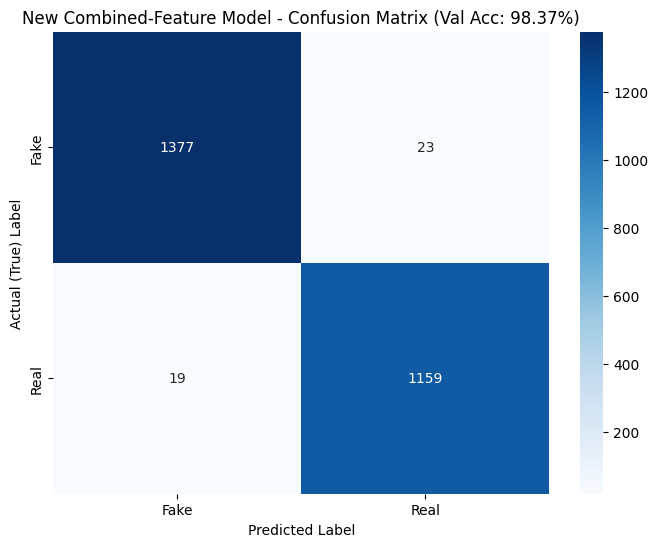

In [ ]:
# EVALUATE THE NEW CLASSIFIER

print("\n--- Evaluation of New Combined-Feature Model on SCALED data ---")

y_pred_raw = new_classifier.predict(X_val_scaled)
y_pred = (y_pred_raw > 0.5).astype(int)


CLASS_NAMES = ['Fake', 'Real']

# CLASSIFICATION REPORT AND CONFUSION MATRIX
print("\n--- New Model: Classification Report ---")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))


print("\n--- New Model: Confusion Matrix ---")
cm = confusion_matrix(y_val, y_pred)
val_accuracy = np.trace(cm) / np.sum(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f'New Combined-Feature Model - Confusion Matrix (Val Acc: {val_accuracy:.2%})')
plt.ylabel('Actual (True) Label')
plt.xlabel('Predicted Label')
plt.show()

In [2]:
# --- (NEW, FIXED Cell 10) ---
# --- Test Your Hybrid Model on a Single, Random Image ---

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 1. SET YOUR IMAGE PATH & LABEL HERE ---
#
# Set 'image_path' to the full path of your new, random image.
#
# Example to test your own file:
image_path = "/kaggle/input/new-images/mobile-04.jpg" # <-- !!! CHANGE THIS LINE !!!
true_label = "Unknown" # (Set this if you know the label, or leave as "Unknown")
#
# Example of testing a validation set image (what we did before):
# image_path = val_paths[1] 
# true_label = 'Real' if val_labels[1] == 1 else 'Fake'
#

print(f"--- Starting prediction for: {image_path} ---")
print(f"    (Known True Label: {true_label})")

# --- 2. Load and Preprocess the Image ---
try:
    # Use the 'load_image_for_extraction' function defined in Cell 6
    img_tensor = load_image_for_extraction(image_path)
    
    if img_tensor is None:
        raise ValueError(f"Image tensor is None. Check file path: {image_path}")

    # --- 3. Extract ResNet Features ---
    image_batch = tf.expand_dims(img_tensor, axis=0)
    resnet_features = feature_extractor_model.predict(image_batch, verbose=0)
    resnet_features_1d = resnet_features[0]

    # --- 4. Extract HOG & DoG Features ---
    image_np_uint8 = img_tensor.numpy().astype(np.uint8)
    hog_features = extract_hog_features(image_np_uint8)
    dog_features = extract_dog_features(image_np_uint8)

    # --- 5. Concatenate All Features ---
    combined_features_1d = np.concatenate([
        resnet_features_1d,
        hog_features,
        dog_features
    ])
    
    # --- 6. Scale Features ---
    # The scaler (from Cell 7) expects a 2D array
    combined_features_2d = combined_features_1d.reshape(1, -1)
    scaled_features = scaler.transform(combined_features_2d)

    # --- 7. Predict with the Final Classifier ---
    # Use the classifier from Cell 8
    prediction_raw = new_classifier.predict(scaled_features, verbose=0)
    prediction_score = prediction_raw[0][0] # Get the single float value
    
    # --- 8. Interpret Result ---
    prediction_class = 'Real' if prediction_score > 0.5 else 'Fake'
    
    # --- Display Results ---
    print("\n--- Prediction Complete ---")
    
    plt.imshow(image_np_uint8)
    plt.title(f"Test Image: {image_path.split('/')[-1]}")
    plt.axis('off')
    plt.show()
    
    print(f"  Actual Label:      {true_label}")
    print(f"  Predicted Label:   {prediction_class}")
    print(f"  Prediction Score:  {prediction_score:.4f} (0='Fake', 1='Real')")
    
    if prediction_class == 'Real':
        print(f"\n  Result: The model is {prediction_score*100:.2f}% confident this is REAL.")
    else:
        print(f"\n  Result: The model is {(1-prediction_score)*100:.2f}% confident this is FAKE.")

except Exception as e:
    print(f"\n--- ERROR ---")
    print(f"An error occurred during prediction: {e}")
    print("This likely means the 'image_path' is incorrect or the image is corrupt.")

--- Starting prediction for: /kaggle/input/new-images/mobile-04.jpg ---
    (Known True Label: Unknown)

--- ERROR ---
An error occurred during prediction: name 'load_image_for_extraction' is not defined
This likely means the 'image_path' is incorrect or the image is corrupt.


Running hybrid prediction on 15 random validation images...


Predicting images: 100%|██████████| 15/15 [00:04<00:00,  3.68it/s]


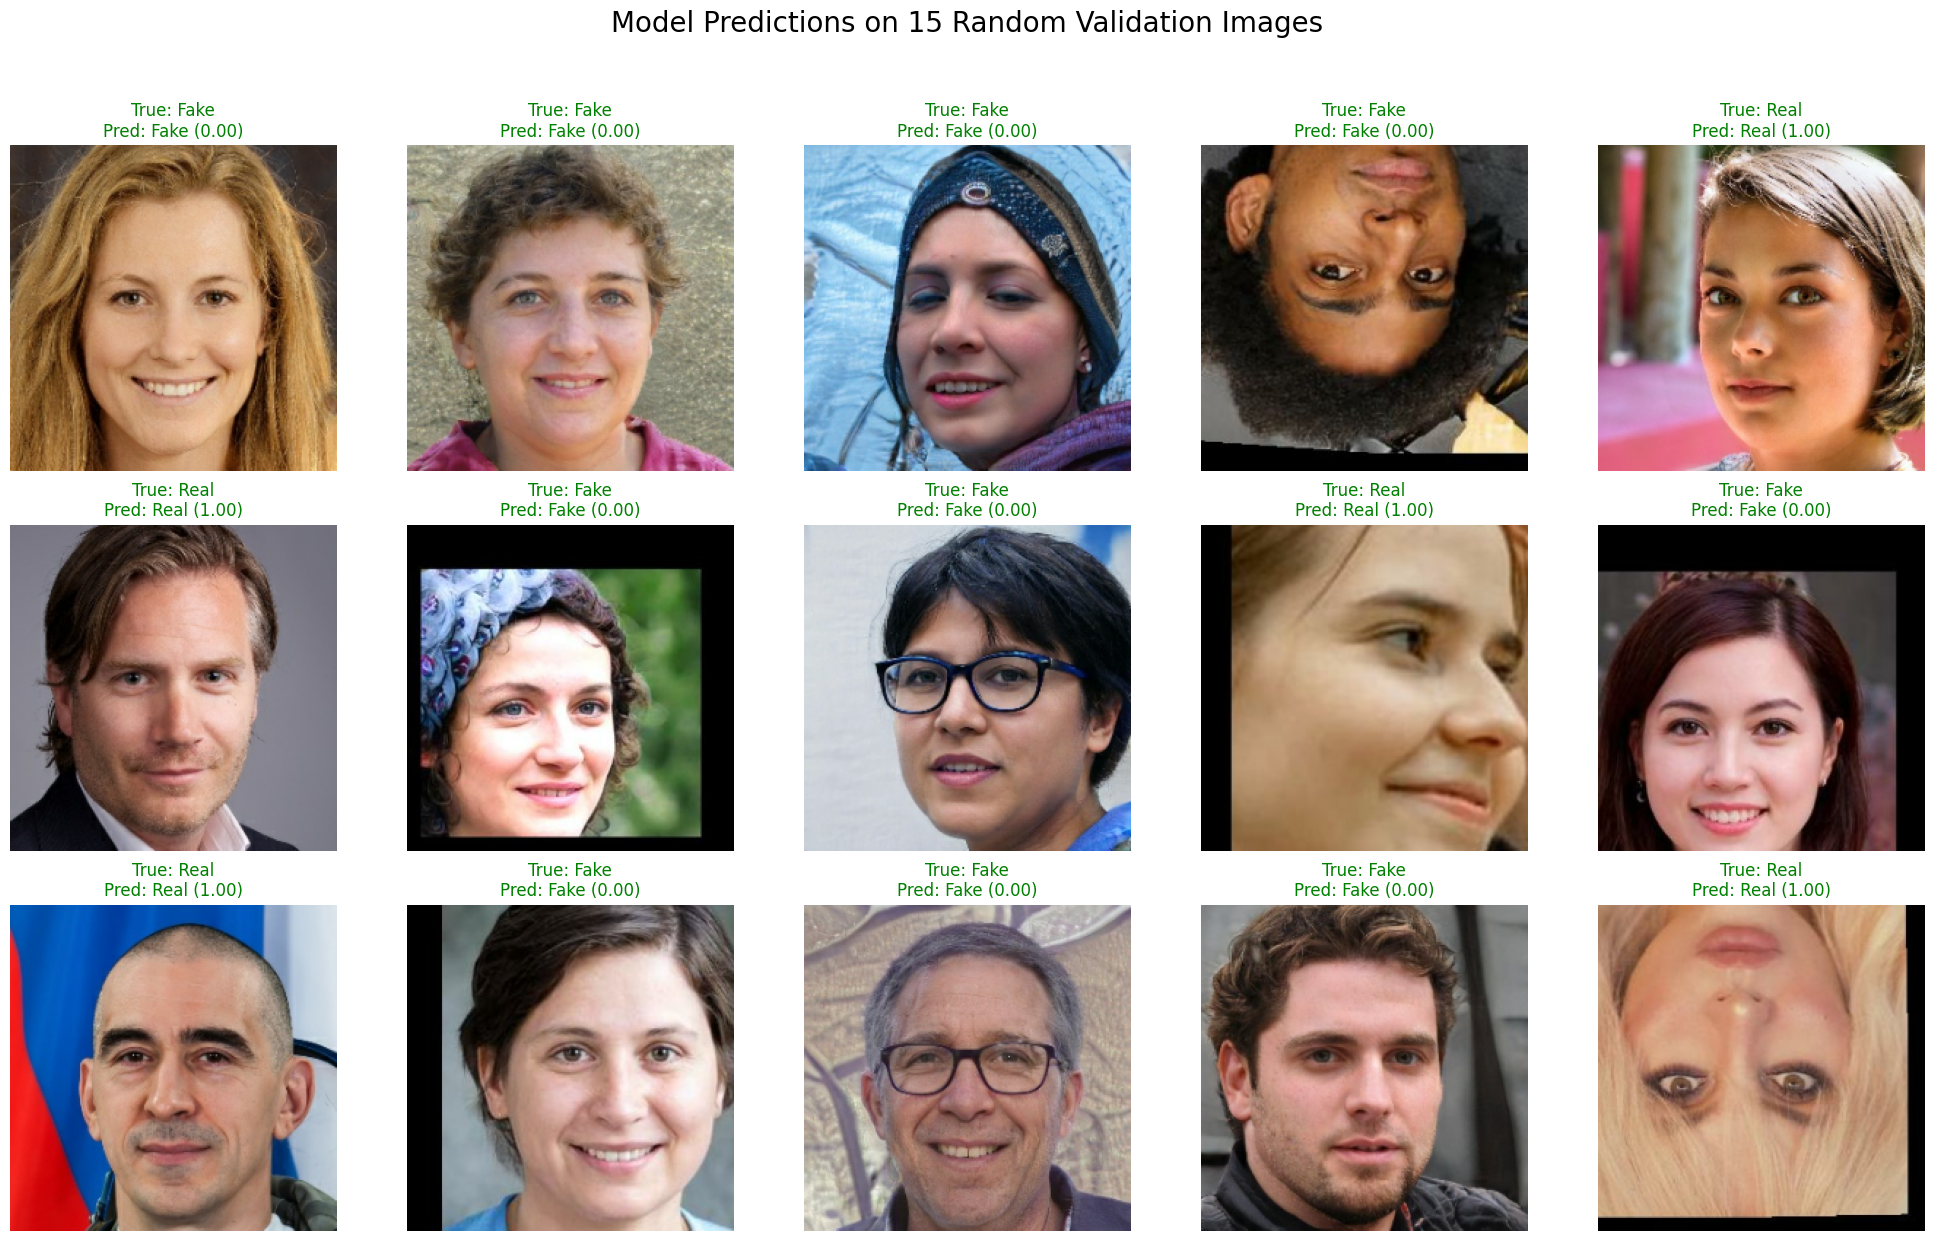

In [ ]:

from tqdm import tqdm 
# A SINGLE FUNCTION TO RUN THE FULL PIPELINE ON ONE IMAGE


def get_hybrid_prediction(image_path):
    """
    Runs the full pipeline on a single image path.
    Returns: (prediction_class, prediction_score, image_tensor)
    """
    try:
        # 1. Load Image
        img_tensor = load_image_for_extraction(image_path)
        if img_tensor is None:
            return "Error", 0.0, None

        # 2. Extract ResNet Features
        image_batch = tf.expand_dims(img_tensor, axis=0)
        resnet_features = feature_extractor_model.predict(image_batch, verbose=0)[0]

        # 3. Extract HOG & DoG Features
        image_np_uint8 = img_tensor.numpy().astype(np.uint8)
        hog_features = extract_hog_features(image_np_uint8)
        dog_features = extract_dog_features(image_np_uint8)

        # 4. Concatenate & Scale
        combined_features = np.concatenate([resnet_features, hog_features, dog_features])
        scaled_features = scaler.transform(combined_features.reshape(1, -1))

        # 5. Predict
        prediction_raw = new_classifier.predict(scaled_features, verbose=0)
        prediction_score = prediction_raw[0][0]
        prediction_class = 'Real' if prediction_score > 0.5 else 'Fake'
        
        return prediction_class, prediction_score, img_tensor
    
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return "Error", 0.0, None


N_IMAGES = 15
fig, axes = plt.subplots(3, 5, figsize=(20, 12)) 

# RANDOM 15 IMAGES FOR TESTING

random_indices = np.random.choice(len(val_paths), N_IMAGES, replace=False)

print(f"Running hybrid prediction on {N_IMAGES} random validation images...")


for i, idx in enumerate(tqdm(random_indices, desc="Predicting images")):
    
    ax = axes[i // 5, i % 5]
    
    path = val_paths[idx]
    true_label = val_labels[idx]
    true_label_str = 'Real' if true_label == 1 else 'Fake'
    
   
    prediction_class, prediction_score, img_tensor = get_hybrid_prediction(path)
    
    if img_tensor is not None:
       
        ax.imshow(img_tensor.numpy().astype(np.uint8))
        color = 'green' if prediction_class == true_label_str else 'red'
        title = f"True: {true_label_str}\nPred: {prediction_class} ({prediction_score:.2f})"
        ax.set_title(title, color=color, fontsize=12)
        
    ax.axis('off')

plt.suptitle("Model Predictions on 15 Random Validation Images", fontsize=20, y=1.03)
plt.tight_layout()
plt.show()